In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Atur gaya visual agar terlihat profesional
sns.set_theme(style="whitegrid", palette="muted")
# 1. Load Data Bersih Anda
df = pd.read_csv('../../data/Data_Cleaned_Wildan.csv')
df['publish_date_wib'] = pd.to_datetime(df['publish_date_wib'])
print("Data berhasil dimuat! Mari kita mulai Exploratory Data Analysis.")

Data berhasil dimuat! Mari kita mulai Exploratory Data Analysis.


# TOP 10 VIDEO PALING SUKSES

/var/folders/1d/lswyqpyj6vd64wxfbp_zhgwc0000gn/T/ipykernel_80526/2219804171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='views', y='video_title', data=top_10_views, palette='viridis')
/Users/wildantaufiqurrahman/capstone/team_work/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wildantaufiqurrahman/capstone/team_work/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8265 (\N{EXCLAMATION QUESTION MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wildantaufiqurrah

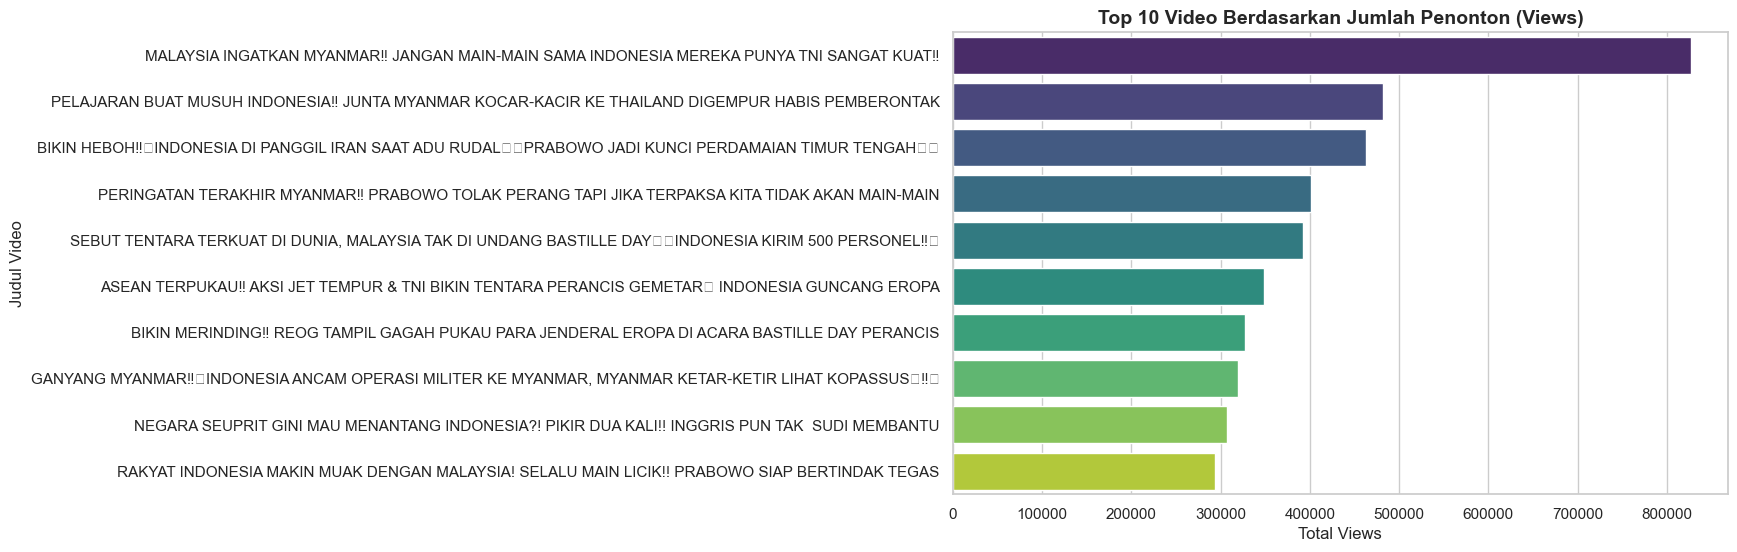

In [3]:
# Mengambil 10 video dengan Views tertinggi
top_10_views = df.nlargest(10, 'views')[['video_title', 'views', 'subscribers']]

plt.figure(figsize=(10, 6))
sns.barplot(x='views', y='video_title', data=top_10_views, palette='viridis')
plt.title('Top 10 Video Berdasarkan Jumlah Penonton (Views)', fontsize=14, fontweight='bold')
plt.xlabel('Total Views')
plt.ylabel('Judul Video')
plt.show()


# Heatmap Korelasi


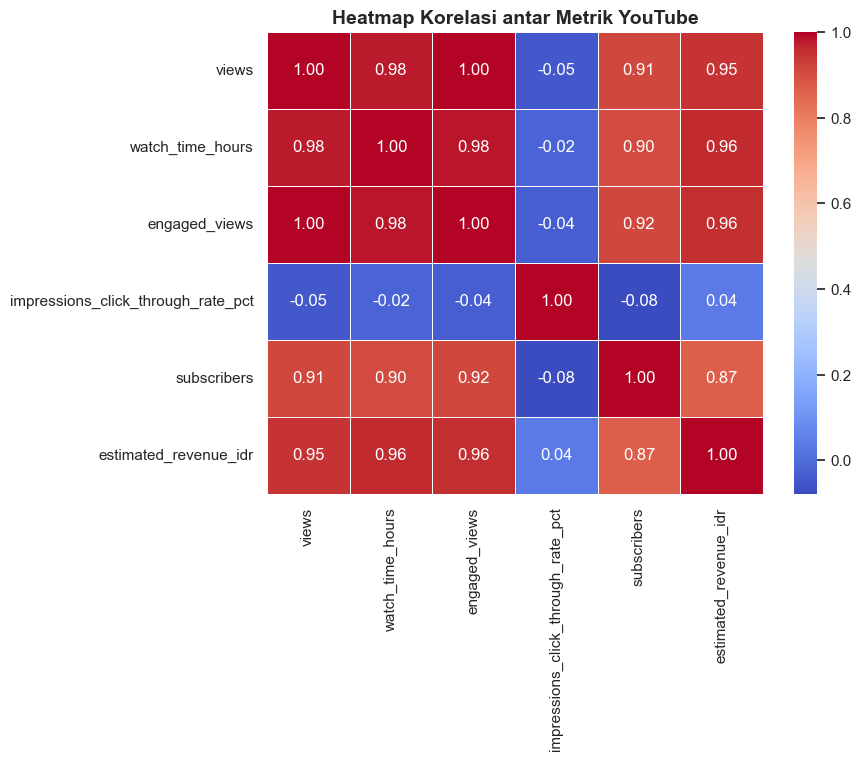

In [4]:
# Memilih kolom numerik penting
kolom_penting = ['views', 'watch_time_hours', 'engaged_views', 
                 'impressions_click_through_rate_pct', 'subscribers', 'estimated_revenue_idr']

plt.figure(figsize=(8, 6))
korelasi = df[kolom_penting].corr()

# Membuat Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi antar Metrik YouTube', fontsize=14, fontweight='bold')
plt.show()


# Kesimpulan dari heatmap diatas antara lain:
1. Dominasi Korelasi Positif yang Sangat Kuat

Terdapat hubungan linear yang hampir sempurna antara beberapa metrik utama:

Views & Engaged Views (1.00): Keduanya memiliki korelasi sempurna. Ini menunjukkan adanya redundansi data. Dalam tahap Data Reduction, Anda mungkin hanya perlu menggunakan salah satu dari fitur ini karena keduanya memberikan informasi yang identik bagi model.   

Views & Watch Time (0.98) & Revenue (0.95): Hubungan ini sangat logis; semakin banyak penonton, semakin tinggi waktu tonton dan pendapatan yang dihasilkan.   

Subscribers & Views (0.91): Ukuran basis audiens (subs) memiliki dampak yang sangat signifikan terhadap volume penayangan dan pendapatan (0.87).

2. Anomali pada CTR (Impressions Click-Through Rate)

Metrik CTR menunjukkan pola yang sangat berbeda dibandingkan metrik lainnya:

Korelasi Mendekati Nol: CTR memiliki korelasi yang sangat rendah bahkan cenderung negatif dengan views (-0.05) dan revenue (0.04).

Kesimpulan: Di dataset ini, CTR yang tinggi tidak selalu menjamin jumlah views atau revenue yang besar secara keseluruhan. Hal ini bisa menjadi indikasi awal untuk tahap Feature Engineering nanti, bahwa CTR mungkin lebih bersifat sebagai metrik efisiensi daripada metrik volume.   

3. Driver Utama Pendapatan (Estimated Revenue)

Jika target model Anda adalah mendiagnosa pendapatan, maka metrik yang paling berpengaruh untuk diperhatikan adalah:

Watch Time (0.96) dan Engaged Views (0.96).

Kedua metrik ini memiliki korelasi sedikit lebih tinggi terhadap pendapatan dibandingkan jumlah views (0.95) saja. Ini menunjukkan bahwa kualitas tontonan (durasi) sangat menentukan nilai ekonomi video tersebut.

4. Relevansi dengan Workflow Anda

Hasil heatmap ini memperkuat langkah-langkah yang Anda susun dalam Resume Data Preparation:

Identifikasi Anomali: Rendahnya korelasi CTR mengonfirmasi perlunya EDA lebih dalam untuk melihat apakah ada outlier pada metrik ini yang memengaruhi distribusi.   

Feature Transformation: Karena korelasi mayoritas metrik sangat tinggi (di atas 0.90), penggunaan Log Transformation yang Anda lakukan sudah tepat untuk menormalisasi skala agar distribusi data lebih merata saat masuk ke model.   
+1

Data Reduction: Angka korelasi 1.00 antara views dan engaged_views adalah sinyal kuat untuk melakukan reduksi fitur agar model tidak mengalami masalah multicollinearity (gangguan karena dua fitur yang terlalu mirip).

# bukti channel sehat 

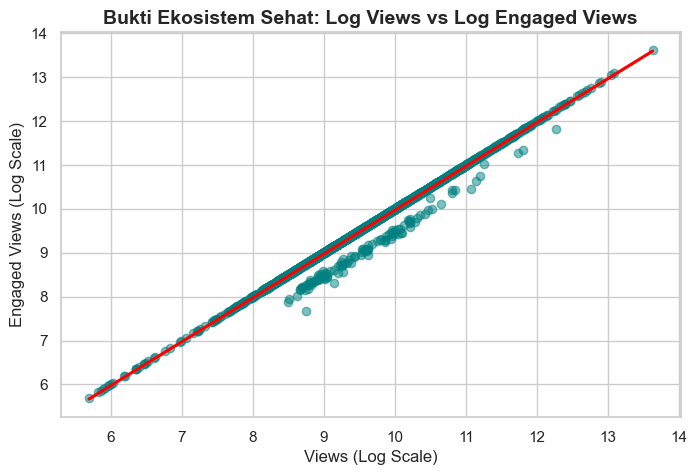

Kesimpulan: Garis merah yang menanjak lurus membuktikan korelasi positif yang sangat kuat (>0.99). Tidak ada 'views hantu', penonton terbukti berinteraksi.


In [5]:
plt.figure(figsize=(8, 5))
# Menggunakan skala logaritmik agar sebaran data terlihat jelas
sns.regplot(x='views_log', y='engaged_views_log', data=df, 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Bukti Ekosistem Sehat: Log Views vs Log Engaged Views', fontsize=14, fontweight='bold')
plt.xlabel('Views (Log Scale)')
plt.ylabel('Engaged Views (Log Scale)')
plt.show()

print("Kesimpulan: Garis merah yang menanjak lurus membuktikan korelasi positif yang sangat kuat (>0.99). Tidak ada 'views hantu', penonton terbukti berinteraksi.")


# Rahasia Pendapatan !

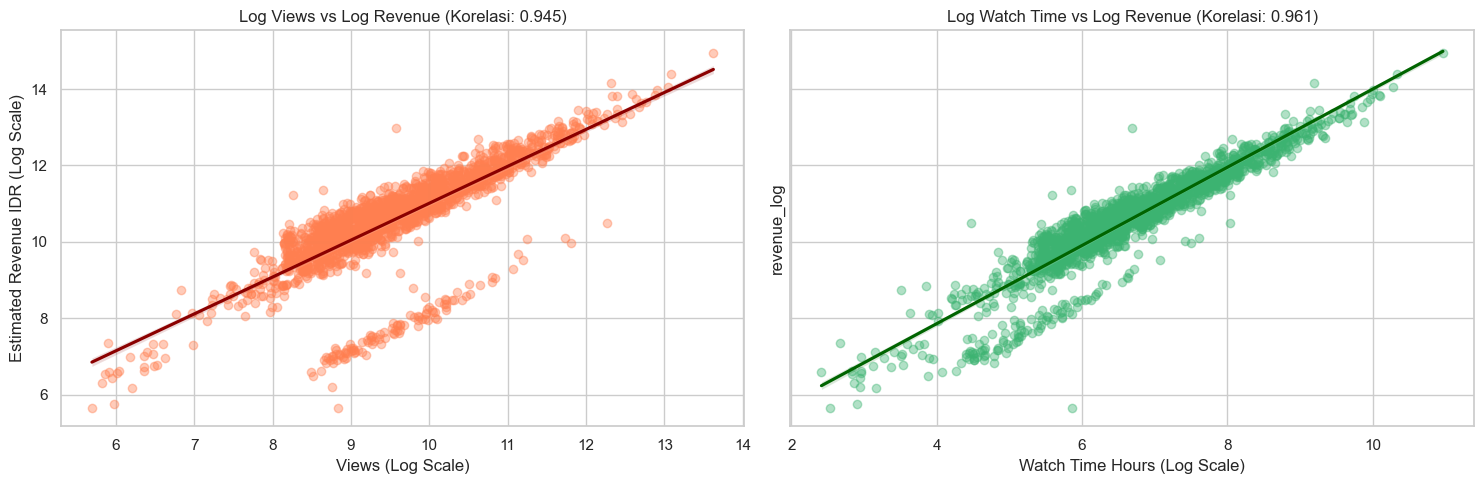

Kesimpulan: Sebaran titik pada 'Watch Time' (hijau) lebih merapat ke garis tren dibandingkan 'Views' (merah). Ini membuktikan durasi tonton lebih menjamin naiknya pendapatan.


In [6]:
# Transformasi Log untuk Pendapatan agar grafik tidak rusak oleh nilai ekstrem
df['revenue_log'] = np.log1p(df['estimated_revenue_idr'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Grafik 1: Views vs Revenue
sns.regplot(x='views_log', y='revenue_log', data=df, ax=axes[0],
            scatter_kws={'alpha':0.4, 'color':'coral'}, line_kws={'color':'darkred'})
axes[0].set_title('Log Views vs Log Revenue (Korelasi: 0.945)')
axes[0].set_xlabel('Views (Log Scale)')
axes[0].set_ylabel('Estimated Revenue IDR (Log Scale)')

# Grafik 2: Watch Time vs Revenue
sns.regplot(x='watch_time_hours_log', y='revenue_log', data=df, ax=axes[1],
            scatter_kws={'alpha':0.4, 'color':'mediumseagreen'}, line_kws={'color':'darkgreen'})
axes[1].set_title('Log Watch Time vs Log Revenue (Korelasi: 0.961)')
axes[1].set_xlabel('Watch Time Hours (Log Scale)')

plt.tight_layout()
plt.show()

print("Kesimpulan: Sebaran titik pada 'Watch Time' (hijau) lebih merapat ke garis tren dibandingkan 'Views' (merah). Ini membuktikan durasi tonton lebih menjamin naiknya pendapatan.")


# Paradoks CTR?

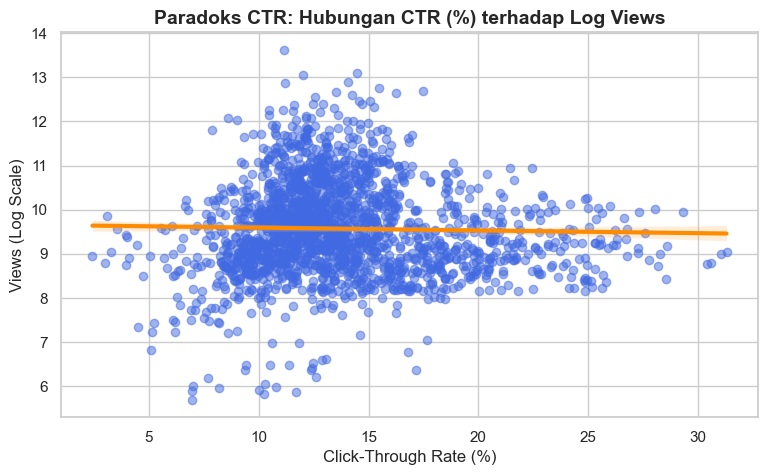

Kesimpulan: Garis tren (oranye) terlihat datar atau bahkan sedikit menurun. Ini membuktikan video dengan CTR tinggi (di ujung kanan) tidak menjamin Views yang tinggi. Seringkali CTR turun saat video viral karena impresinya disebar ke non-subscriber.


In [7]:
plt.figure(figsize=(9, 5))
# Menampilkan garis tren untuk melihat arah kemiringannya
sns.regplot(x='impressions_click_through_rate_pct', y='views_log', data=df, 
            scatter_kws={'alpha':0.5, 'color':'royalblue'}, line_kws={'color':'darkorange', 'linewidth':3})

plt.title('Paradoks CTR: Hubungan CTR (%) terhadap Log Views', fontsize=14, fontweight='bold')
plt.xlabel('Click-Through Rate (%)')
plt.ylabel('Views (Log Scale)')
plt.show()

print("Kesimpulan: Garis tren (oranye) terlihat datar atau bahkan sedikit menurun. Ini membuktikan video dengan CTR tinggi (di ujung kanan) tidak menjamin Views yang tinggi. Seringkali CTR turun saat video viral karena impresinya disebar ke non-subscriber.")
